# Example of the AiTLAS toolbox for generating feature embeddings using Copernicus-FM

## Define the FAIREOSchema for dataset import

In [1]:
from marshmallow import fields

from aitlas.base.schemas import BaseDatasetSchema


class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for FAIREO datasets.
    """

    csv_file = fields.String(
        load_default=None,
        metadata={"description": "CSV file on disk", "example": "./data/train.csv"},
    )
    data_dir = fields.String(
        load_default="/",
        metadata={"description": "Dataset path on disk", "example": "./data/CESBIO/"},
    )
    selection = fields.String(
        load_default="rgb",
        metadata={"description": "Read RGB channels or 13 channels", "example": "all/rgb"},
    )

## Define the South Africa Crop Type competition dataset
This dataset was produced as part of the Radiant Earth Spot the Crop Challenge (https://zindi.africa/hackathons/radiant-earth-spot-the-crop-hackathon). The objective of the competition was to create a machine learning model to classify fields by crop type from images collected during the growing season by the Sentinel-2 and Sentinel-1 satellites.

In [2]:
import fnmatch
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
from matplotlib.patches import Patch
from pyproj import Transformer

from aitlas.datasets.semantic_segmentation import SemanticSegmentationDataset
from aitlas.utils import image_loader


class SACropTypeDataset(SemanticSegmentationDataset):
    """
    Radiant Earth Spot the Crop Challenge Dataset
    - Loads time-series data for Sentinel-1 or Sentinel-2.
    - Generates per-pixel latitude and longitude coordinates for each sample.
    """

    url = "https://source.coop/repositories/radiantearth/south-africa-crops-competition/access"

    labels = [
        "no-data",
        "lucerne/medics",
        "planted pastures",
        "fallow",
        "wine grapes",
        "weeds",
        "small grain grazing",
        "wheat",
        "canola",
        "rooibos",
    ]
    color_mapping = [
        [0, 0, 0],
        [255, 0, 0],
        [255, 255, 0],
        [192, 192, 0],
        [0, 255, 0],
        [125, 125, 125],
        [0, 0, 255],
        [0, 255, 255],
        [198, 196, 255],
        [0, 0, 192],
    ]
    name = "SA Crop Type"
    schema = FAIREOSchema

    def __init__(self, config):
        super().__init__(config)
        self.data_dir = self.config.data_dir
        self.selection = self.config.selection
        self.csv_file = self.config.csv_file
        self.date = None  # Set to an integer index to load a single date

    def dataloader(self):
        """Create and return a dataloader for the dataset."""
        return torch.utils.data.DataLoader(
            self,
            batch_size=self.batch_size,
            shuffle=self.shuffle,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
            collate_fn=lambda x: x,
        )

    def __getitem__(self, index):
        # Generate the lat/lon coordinate tensor
        is_s1 = fnmatch.fnmatch(self.data_dir, "*/s1/*")
        is_s2 = fnmatch.fnmatch(self.data_dir, "*/s2/*")

        if is_s1:
            ref_image_path = self.images_VH[index][0]
        elif is_s2:
            ref_image_path = self.images["images_B02"][index][0]
        else:
            raise ValueError("Data directory not recognized as S1 or S2.")

        with rasterio.open(ref_image_path) as src:
            height, width = src.height, src.width
            transform, crs = src.transform, src.crs
            cols, rows = np.meshgrid(np.arange(width), np.arange(height))
            xs, ys = rasterio.transform.xy(transform, rows, cols, offset="center")

            proj_transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
            lons, lats = proj_transformer.transform(np.array(xs), np.array(ys))

            latlons = np.stack([lats, lons]).reshape(2, height, width).astype(np.float32)

        # Load the time-series or single-date image data
        s2_bands = [
            "B01",
            "B02",
            "B03",
            "B04",
            "B05",
            "B06",
            "B07",
            "B08",
            "B8A",
            "B09",
            "B11",
            "B12",
        ]

        if self.date is None:  # Load the whole time series
            image_list = []
            if is_s1:
                for i in range(len(self.images_VH[index])):
                    image_VH = image_loader(self.images_VH[index][i])
                    image_VV = image_loader(self.images_VV[index][i])
                    image_step = np.dstack((image_VH, image_VV))
                    image_list.append(image_step)

            if is_s2:
                num_timesteps = len(self.images["images_B02"][index])
                for i in range(num_timesteps):
                    bands_for_step = []
                    for band in s2_bands:
                        band_path = self.images[f"images_{band}"][index][i]
                        bands_for_step.append(image_loader(band_path))
                    image_step = np.dstack(bands_for_step)
                    image_list.append(image_step)

            image = np.array(image_list)

        else:  # Load imagery for a specific date index
            date = self.date
            if is_s1:
                image_VV = image_loader(self.images_VV[index][date])
                image_VH = image_loader(self.images_VH[index][date])
                image = np.dstack((image_VH, image_VV))

            if is_s2:
                bands_for_step = []
                for band in s2_bands:
                    band_path = self.images[f"images_{band}"][index][date]
                    bands_for_step.append(image_loader(band_path))
                image = np.dstack(bands_for_step)

        # Load mask and apply transformations
        mask = image_loader(self.masks[index])
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")

        image, mask = self.apply_transformations(image, mask)

        return image, mask, latlons

    def __len__(self):
        return len(self.masks)

    def load_dataset(self, data_dir, csv_file):
        if not self.labels:
            raise ValueError("You need to provide the list of labels for the dataset")

        regions = os.listdir(os.path.join(data_dir, "imagery"))
        self.masks = [os.path.join(data_dir, "labels", image_id + ".tif") for image_id in regions]

        if fnmatch.fnmatch(data_dir, "*/s1/*"):
            self.images_VH = []
            self.images_VV = []
            for i in regions:
                images_per_region_VH = []
                images_per_region_VV = []
                dates = sorted(os.listdir(os.path.join(data_dir, "imagery", i)))
                for j in dates:
                    for h in os.listdir(os.path.join(data_dir, "imagery", i, j)):
                        if fnmatch.fnmatch(h, "*_VH_10m.tif"):
                            images_per_region_VH.append(os.path.join(data_dir, "imagery", i, j, h))
                        if fnmatch.fnmatch(h, "*_VV_10m.tif"):
                            images_per_region_VV.append(os.path.join(data_dir, "imagery", i, j, h))
                self.images_VH.append(images_per_region_VH)
                self.images_VV.append(images_per_region_VV)

        if fnmatch.fnmatch(data_dir, "*/s2/*"):
            s2_bands = [
                "B01",
                "B02",
                "B03",
                "B04",
                "B05",
                "B06",
                "B07",
                "B08",
                "B8A",
                "B09",
                "B11",
                "B12",
            ]
            self.images = {f"images_{band}": [] for band in s2_bands}

            for i in regions:
                images_per_region = {f"images_per_region_{band}": [] for band in s2_bands}
                dates = sorted(os.listdir(os.path.join(data_dir, "imagery", i)))
                for j in dates:
                    files_in_date = os.listdir(os.path.join(data_dir, "imagery", i, j))
                    for band in s2_bands:
                        # Find the file for the current band
                        pattern = f"*_{band}_10m.tif"
                        file_match = fnmatch.filter(files_in_date, pattern)
                        if file_match:
                            images_per_region[f"images_per_region_{band}"].append(
                                os.path.join(data_dir, "imagery", i, j, file_match[0])
                            )

                for band in s2_bands:
                    self.images[f"images_{band}"].append(
                        images_per_region[f"images_per_region_{band}"]
                    )

    def show_image(self, index, show_title=False):
        # This method might need adjustment if you use transformations that change the output type
        # For simplicity, we assume it's called on the raw, untransformed data
        raw_image, raw_mask, _ = self.__getitem__(
            index
        )  # We get the raw data before transformations

        # If image is a time-series, show the first timestep
        if raw_image.ndim == 4:
            img_to_show = raw_image[0]
        else:
            img_to_show = raw_image

        # For S1, plot VH band; for S2, plot B04 (Red) as an example
        if img_to_show.shape[2] == 2:  # S1
            img_to_show = img_to_show[:, :, 0]  # VH
        else:  # S2
            img_to_show = img_to_show[:, :, 3]  # B04

        img_mask = np.zeros([raw_mask.shape[0], raw_mask.shape[1], 3], np.uint8)
        legend_elements = []
        for i, label in enumerate(self.labels):
            legend_elements.append(
                Patch(
                    facecolor=tuple([x / 255 for x in self.color_mapping[i]]), label=self.labels[i]
                )
            )
            img_mask[np.where(raw_mask[:, :, i] == 1)] = self.color_mapping[i]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        fig.legend(handles=legend_elements, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))
        ax1.imshow(img_to_show, cmap="gray")
        ax1.set_title("Image")
        ax1.axis("off")
        ax2.imshow(img_mask)
        ax2.set_title("Mask")
        ax2.axis("off")
        fig.tight_layout()
        plt.show()
        return fig

    def show_timeseries(self, index, longitude, latitude):
        # This function assumes pixel coordinates (longitude, latitude) are (row, col) indices
        image, label, _ = self.__getitem__(index)

        # Make sure image is a time-series
        if image.ndim != 4:
            print("show_timeseries can only be called on a full time-series.")
            return

        location_timeseries = image[:, longitude, latitude, :]  # T x C

        # Get the label name for the specified pixel
        crop_index = np.argmax(label[longitude, latitude, :])
        crop_name = self.labels[crop_index]

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_title(
            f"Time series for pixel ({longitude}, {latitude}), Label: {crop_name}\n",
            fontsize=14,
        )
        ax.plot(location_timeseries)

        if location_timeseries.shape[1] == 2:
            ax.legend(["VH", "VV"])
        else:
            ax.legend(
                ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]
            )

        ax.set_ylabel("Value")
        ax.set_xlabel("Time Step")
        return fig

    def data_distribution_table(self):
        label_dist = {key: 0 for key in self.labels}
        for i in range(len(self.masks)):
            _, mask, _ = self[i]
            for index, label in enumerate(self.labels):
                label_dist[self.labels[index]] += mask[:, :, index].sum()
        label_count = pd.DataFrame.from_dict(label_dist, orient="index")
        label_count.columns = ["Number of pixels"]
        label_count = label_count.astype(float)
        return label_count

/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/eolearn/__init__.py:13: UserWarning: You are currently using an outdated installation of `eo-learn` for submodules ['core', 'geometry']. You can find instructions on how to install `eo-learn` correctly at https://github.com/sentinel-hub/eo-learn/issues/733.
  warnings.warn(
/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare the model

In [12]:
from aitlas.models import CopernicusFM


model_config = {
    "local_model_path": "tests/checkpoints/CopernicusFM_ViT_base_varlang_e100.pth",
    "backbone_name": "copernicusfm_base",
    "pretrained": True,
}

"""model_config = {
    "local_model_path": "tests/checkpoints/CopernicusFM_ViT_large_varlang_e100.pth",
    "backbone_name": "copernicusfm_large",
    "pretrained": True
}"""

model = CopernicusFM(model_config)
device = "cuda:1" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Model loaded on device: {device}")

Loading weights from the provided local path: tests/checkpoints/CopernicusFM_ViT_base_varlang_e100.pth
Successfully loaded checkpoint: CopernicusFM_ViT_base_varlang_e100.pth
Model loaded on device: cuda:1


## Examples

### 1. Sentinel-2 example

Load an example dataset with Sentinel-2 images

In [4]:
# Sentinel-2
dataset_s2_config = {"data_dir": "/home/dragik/data/FAIR_EO/sa_crop_type/s2/train"}
dataset_s2 = SACropTypeDataset(dataset_s2_config)

print(f"Total number of images for Sentinel-2 images: {len(dataset_s2)}")

Total number of images for Sentinel-2 images: 2650


Define the utility function to load the Sentinel-2 images

In [5]:
import torch


def load_s2(dataset_s2, num_images, device):

    # Ensure the number of images requested does not exceed dataset size
    num_images = min(num_images, len(dataset_s2))

    # Preallocate the lists
    images_list = []
    masks_list = []
    latlons_list = []
    timestamps_list = []

    for i in range(num_images):
        images, masks, latlons = dataset_s2[i]

        # Skip empty entries
        if images.shape[0] == 0:
            continue

        images_list.append(images)
        masks_list.append(masks)
        latlons_list.append(latlons)

        # Extract timestamps for this image
        timestamps = []
        for j in range(images.shape[0]):
            filename = os.path.basename(dataset_s2.images["images_B01"][i][j])
            ts_parts = filename.split("_")[1:4]
            timestamps.append(f"{ts_parts[0]}-{ts_parts[1]}-{ts_parts[2]}")
        timestamps_list.append(timestamps)

    # Find the minimum number of time steps from the loaded data
    if not images_list:
        print("No valid images found to load.")
        return None, None, None, None

    min_timesteps = min(img.shape[0] for img in images_list)

    # Process and sort the loaded data
    final_images_list = []
    final_masks_list = []
    final_timestamps_list = []

    for i in range(len(images_list)):
        images = images_list[i]
        masks = masks_list[i]
        timestamps = timestamps_list[i]

        # Sort timestamps and get indices
        sorted_indices = np.argsort(timestamps)

        # Trim to min_timesteps before sorting
        sorted_indices = sorted_indices[:min_timesteps]

        # Apply trimming and sorting
        images = images[sorted_indices, :, :, :]
        timestamps = [timestamps[idx] for idx in sorted_indices]

        final_images_list.append(torch.tensor(images, device=device, dtype=torch.float32))
        final_masks_list.append(torch.tensor(masks, device=device, dtype=torch.float32))
        final_timestamps_list.append(timestamps)

    # Stack the final lists into tensors
    images_tensor = torch.stack(final_images_list, dim=0)
    masks_tensor = torch.stack(final_masks_list, dim=0)
    latlons_tensor = torch.stack(
        [torch.tensor(lat, device=device, dtype=torch.float32) for lat in latlons_list], dim=0
    )

    # Reshape the images tensor
    images_tensor = images_tensor.permute(0, 1, 4, 2, 3)  # (B, T, H, W, C) -> (B, T, C, H, W)

    return images_tensor, masks_tensor, latlons_tensor, final_timestamps_list

In [6]:
import datetime

import torch


def process_timestamps(timestamps_batch, device):
    """
    Extracts year and day_of_year from a batch of timestamp lists.

    Args:
      timestamps_batch: A list of lists of strings (shape [B, T]),
                        where each string is 'YYYY-MM-DD'.

    Returns:
      A torch.Tensor of shape [B, T, 2] containing [year, day_of_year]
    """

    # Iterate through each item in the batch (B)
    batch_results = []
    for timestamps_list in timestamps_batch:
        # Iterate through each timestamp in the sequence (T)
        time_results = []
        for ts_str in timestamps_list:
            # Parse the string
            dt_obj = datetime.datetime.strptime(ts_str, "%Y-%m-%d")
            # Define the baseline date
            dt_baseline = datetime.datetime(1970, 1, 1)
            # Get the number of days since baseline
            delta = dt_obj - dt_baseline
            delta_days = delta.days
            # Append the number of days since baseline
            time_results.append([delta_days])

        # Append the results to batch
        batch_results.append(time_results)

    # Convert the nested list to a PyTorch tensor
    return torch.tensor(batch_results, dtype=torch.float32, device=device)

Load and process the data, so that it is suitable for Copernicus-FM

In [7]:
import torch
from torchvision.transforms import v2


# Load Sentinel-2 data
num_image_batches = 3
s2_images_tensor, s2_masks_tensor, latlons_tensor, s2_timestamps_list = load_s2(
    dataset_s2, num_image_batches, device=device
)

# Center crop the images and masks
transforms = v2.Compose([v2.CenterCrop(224)])
# Images
s2_images_tensor = transforms(s2_images_tensor)
s2_bands = {
    "B01": 0.443,
    "B02": 0.490,
    "B03": 0.560,
    "B04": 0.665,
    "B05": 0.705,
    "B06": 0.740,
    "B07": 0.783,
    "B08": 0.842,
    "B8A": 0.865,
    "B09": 0.945,
    "B11": 1.610,
    "B12": 2.190,
}  # No B10
s2_bandwidths = {
    "B01": 0.020,
    "B02": 0.065,
    "B03": 0.035,
    "B04": 0.030,
    "B05": 0.015,
    "B06": 0.015,
    "B07": 0.020,
    "B08": 0.115,
    "B8A": 0.020,
    "B09": 0.020,
    "B11": 0.090,
    "B12": 0.180,
}
s2_band_indices = {
    "B01": 0,
    "B02": 1,
    "B03": 2,
    "B04": 3,
    "B05": 4,
    "B06": 5,
    "B07": 6,
    "B08": 7,
    "B8A": 8,
    "B09": 9,
    "B11": 10,
    "B12": 11,
}

# Select the bands to use
inds = [1, 2, 3, 7]  # B, G, R, NIR

# Take just one timestep (Copernicus-FM expects a single timestep as input)
s2_images_tensor_truncated = s2_images_tensor[:, 0, inds, :, :]

# Masks
s2_masks_tensor = s2_masks_tensor.permute(3, 0, 1, 2)
s2_masks_tensor = transforms(s2_masks_tensor)
s2_masks_tensor = s2_masks_tensor.permute(1, 2, 3, 0)

# Prepare the metadata
# 1. Prepare the latitude/longitude tensor (take just the coordinates from the center of the image)
latlons_tensor = latlons_tensor[
    :, :, int(latlons_tensor.shape[2] / 2), int(latlons_tensor.shape[3] / 2)
]
# 2. Prepare the timestamp
s2_timestamps_tensor = process_timestamps(s2_timestamps_list, device)
s2_timestamps_tensor = s2_timestamps_tensor[:, 0, :]  # Take just the first timestep
# 3. Prepare the patch area
patch_area = (
    16 * 10 / 1000
) ** 2  # in km^2; patch size is 16x16 pixels and GSD is 10m for bands B02, B03, B04, B08
patch_area_tensor = torch.full(
    (s2_images_tensor_truncated.shape[0], 1), patch_area, device=device, dtype=torch.float32
)
# Construct the metadata tensor
metadata_tensor = torch.cat([latlons_tensor, s2_timestamps_tensor, patch_area_tensor], dim=1)

# Define the wavelengths and the bandwidths (must be a list of integers)
wavelengths = [
    int(1000 * s2_bands[key]) for key in s2_bands.keys()
]  # Convert to nm, according to docstring
wavelengths = [wavelengths[i] for i in inds]
bandwidths = [
    int(1000 * s2_bandwidths[key]) for key in s2_bands.keys()
]  # Convert to nm, according to docstring
bandwidths = [bandwidths[i] for i in inds]

print("Sentinel-2:")
print(f"Images tensor shape: {s2_images_tensor_truncated.shape}")  # Expected shape: (B, C, H, W)
print(f"Latlons tensor shape: {latlons_tensor.shape}")  # Expected shape: (B, 2)
print(f"Latlons tensor: {latlons_tensor}")
print(f"Timestamp tensor shape: {s2_timestamps_tensor.shape}")  # Expected shape: (B, 1)
print(f"Timestamps tensor: {s2_timestamps_tensor}")
print(f"Patch area tensor shape: {patch_area_tensor.shape}")  # Expected shape: (B, 1)
print(f"Patch area tensor: {patch_area_tensor}")
print(f"Metadata tensor shape: {metadata_tensor.shape}")  # Expected shape: (B, 4)
print(f"Metadata tensor: {metadata_tensor}")
print(f"Wavelengths list length: {len(wavelengths)}")  # Expected shape: (C,)
print(f"Wavelengths list: {wavelengths}")
print(f"Bandwidths list length: {len(bandwidths)}")  # Expected shape: (C,)
print(f"Bandwidths list: {bandwidths}")

Sentinel-2:
Images tensor shape: torch.Size([3, 4, 224, 224])
Latlons tensor shape: torch.Size([3, 2])
Latlons tensor: tensor([[-32.7845,  18.0071],
        [-33.7465,  18.7477],
        [-33.0398,  19.3140]], device='cuda:1')
Timestamp tensor shape: torch.Size([3, 1])
Timestamps tensor: tensor([[17257.],
        [17257.],
        [17257.]], device='cuda:1')
Patch area tensor shape: torch.Size([3, 1])
Patch area tensor: tensor([[0.0256],
        [0.0256],
        [0.0256]], device='cuda:1')
Metadata tensor shape: torch.Size([3, 4])
Metadata tensor: tensor([[-3.2785e+01,  1.8007e+01,  1.7257e+04,  2.5600e-02],
        [-3.3746e+01,  1.8748e+01,  1.7257e+04,  2.5600e-02],
        [-3.3040e+01,  1.9314e+01,  1.7257e+04,  2.5600e-02]], device='cuda:1')
Wavelengths list length: 4
Wavelengths list: [490, 560, 665, 842]
Bandwidths list length: 4
Bandwidths list: [65, 35, 30, 115]


Plot the Sentinel-2 images and masks

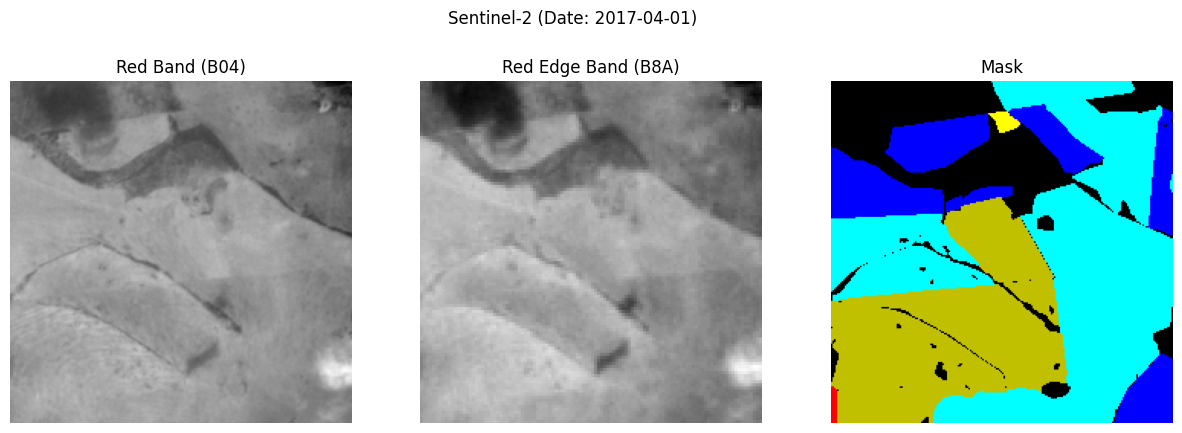

In [8]:
# Define the color mapping from your dataset
color_mapping = [
    [0, 0, 0],
    [255, 0, 0],
    [255, 255, 0],
    [192, 192, 0],
    [0, 255, 0],
    [125, 125, 125],
    [0, 0, 255],
    [0, 255, 255],
    [198, 196, 255],
    [0, 0, 192],
]

# Select the first image and mask from the batch
image_to_plot = s2_images_tensor[0, 0].cpu().numpy()
mask_to_plot = s2_masks_tensor[0].cpu().numpy()

# Select the Red band (B04), at index 3 in the 12-band tensor
red_band = image_to_plot[3, :, :]

# Select the Near-Infrared band (B8A), at index 8
red_edge_band = image_to_plot[8, :, :]

# Create the colorized segmentation mask
class_map = np.argmax(mask_to_plot, axis=-1)
rgb_mask = np.zeros((class_map.shape[0], class_map.shape[1], 3), dtype=np.uint8)
for class_index, color in enumerate(color_mapping):
    rgb_mask[class_map == class_index] = color

# Create a figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Sentinel-2 (Date: {s2_timestamps_list[0][0]})")

# Plot the Red band
ax1.imshow(red_band, cmap="gray")
ax1.set_title("Red Band (B04)")
ax1.axis("off")

# Plot the NIR band
ax2.imshow(red_edge_band, cmap="gray")
ax2.set_title("Red Edge Band (B8A)")
ax2.axis("off")

# Plot the combined segmentation mask
ax3.imshow(rgb_mask)
ax3.set_title("Mask")
ax3.axis("off")

plt.show()

Infer the model

In [11]:
# Get the feature embedding
embedding = model.forward_features(
    x=s2_images_tensor_truncated,
    metadata=metadata_tensor,
    wavelengths=wavelengths,
    bandwidths=bandwidths,
)

print(f"Embeddings shape: {embedding.shape}")  # Output: torch.Tensor of shape (B, D)

Embeddings shape: torch.Size([3, 1024])
